In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd
df_news_final_project = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')
df_news_final_project.shape

(199989, 5)

In [34]:
print("Columns:")
print(df_news_final_project.columns)

print("\nData types:")
print(df_news_final_project.dtypes)

Columns:
Index(['url', 'date', 'language', 'title', 'text'], dtype='object')

Data types:
url         object
date        object
language    object
title       object
text        object
dtype: object


In [35]:
print("Missing values:")
print(df_news_final_project.isnull().sum())

Missing values:
url         0
date        0
language    0
title       0
text        0
dtype: int64


In [36]:
text_col = "text"

df_news_final_project["word_count"] = (
    df_news_final_project[text_col]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print(df_news_final_project["word_count"].describe())

count    199989.000000
mean       1231.988419
std         963.096173
min           4.000000
25%         704.000000
50%        1034.000000
75%        1548.000000
max       39964.000000
Name: word_count, dtype: float64


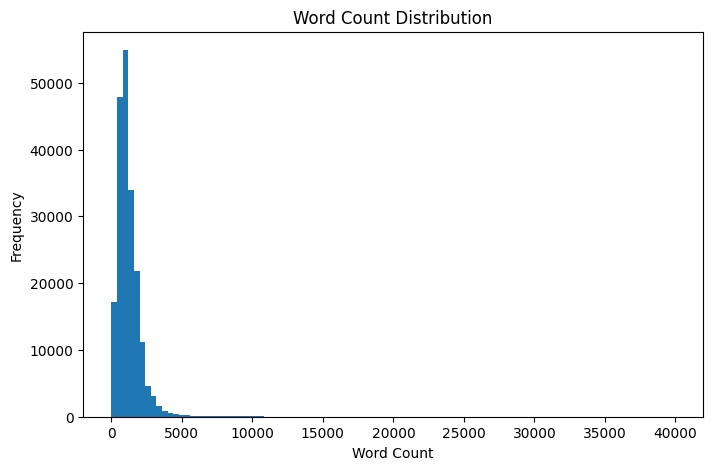

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_news_final_project["word_count"], bins=100)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [38]:
print(
    "Duplicate content rows:",
    df_news_final_project.duplicated(subset=[text_col]).sum()
)

Duplicate content rows: 494


In [39]:
for i in range(3):
    print("\n--- Sample Article ---\n")
    print(df_news_final_project[text_col].iloc[i][:1000])


--- Sample Article ---

Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Idea AI price (BAD)Bad Idea AIBADLive Bad Idea AI price updates and the latest Bad Idea AI news.pricesponsored byBlockworks Research$0.0000000112$0(0%)24h low$0.0000000124h high$0.00000001PriceMarket Cap1D7D1M3M1YYTDALLVSUSDUSDBTCBTC TradingView ChartLinearLogarithmicThe live Bad Idea AI price today is $0.00000001 with a 24-hour trading volume of $1.51M. The table above accurately updates our BAD price in real time. The price of BAD is down -0.61% since last hour, up 9.75% since yesterday. The live market cap, measured by multiplying the number of coins by the current price is $9.30M. BAD has a circulating supply of 668.96T coins and a max supply of 829.49T BAD.Bad Idea AI StatsWhat is the market cap of Bad Idea AI?The current market cap of Bad Idea AI is $7.52M. A high 

In [40]:
df_news_final_project = df_news_final_project[
    df_news_final_project["language"] == "en"
]
print("After keeping English only:", df_news_final_project.shape)

After keeping English only: (199989, 6)


In [41]:
noise_keywords = [
    "menu",
    "search",
    "privacy policy",
    "advertise",
    "contact us",
    "terms of service",
    "store",
    "newsletter",
    "tradingview",
    "market cap",
    "price today",
    "24h low",
    "24h high",
    "circulating supply"
]

In [42]:
cut_markers = [
    "privacy policy",
    "advertise",
    "contact us",
    "terms of service",
    "newsletter",
]

def remove_footer(text):
    text_lower = text.lower()
    cut_positions = [
        text_lower.find(marker)
        for marker in cut_markers
        if marker in text_lower
    ]

    if cut_positions:
        cut_at = min(cut_positions)
        return text[:cut_at]

    return text

df_news_final_project["clean_text"] = (
    df_news_final_project["text"]
    .astype(str)
    .apply(remove_footer)
)

In [43]:
df_news_final_project["word_count"] = (
    df_news_final_project["text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

df_news_final_project = df_news_final_project[
    df_news_final_project["word_count"] > 200
]

print("After length filter:", df_news_final_project.shape)

After length filter: (189351, 7)


In [44]:
df_news_final_project = df_news_final_project.drop_duplicates(
    subset=["text"]
)

print("After dedup:", df_news_final_project.shape)

After dedup: (188910, 7)


In [45]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

df_news_final_project["processed_text"] = (
    df_news_final_project["clean_text"]
    .astype(str)
    .apply(preprocess_text)
)

In [46]:
df_news_final_project.to_parquet(
    "/content/drive/MyDrive/NLP_AI_Impact_Project/data/cleaned_data.parquet"
)